0.0
0.015789473684210527
0.031578947368421054
0.04736842105263158
0.06315789473684211
0.07894736842105263
0.09473684210526316
0.1105263157894737
0.12631578947368421
0.14210526315789473
0.15789473684210525
0.1736842105263158
0.18947368421052632
0.20526315789473684
0.2210526315789474
0.2368421052631579
0.25263157894736843
0.26842105263157895
0.28421052631578947
0.3
0.31
0.3463157894736842
0.38263157894736843
0.4189473684210526
0.4552631578947368
0.49157894736842106
0.5278947368421052
0.5642105263157895
0.6005263157894737
0.6368421052631579
0.6731578947368422
0.7094736842105263
0.7457894736842106
0.7821052631578947
0.8184210526315789
0.8547368421052632
0.8910526315789473
0.9273684210526316
0.9636842105263157
1.0


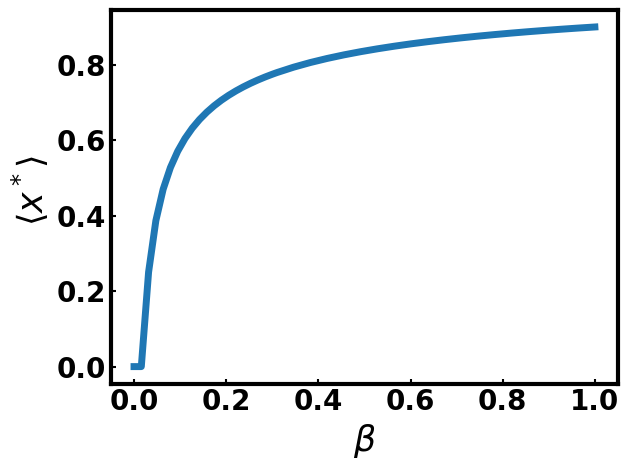

In [1]:

"""
NEAR TC , GCC ADJANCENY MATRIX 293 
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.io


beta_values = np.concatenate((np.linspace(0, 0.3, 20), np.linspace(0.31,1,20)))    
T_max = 10000  
t_eval = np.linspace(0, T_max, 10000)

theo_avg = []
theo_star = []
theo_star1 = []

network_data =np.loadtxt("A_near_GCC.csv", delimiter=",")
# network_data =np.loadtxt('C:/Users/Admin/Desktop/python/work_1/EFFECT OF POPULATION ABUNDANCES-PRE/er_p_0.02_n_500.txt',float)
#network_data = scipy.io.loadmat('/home/meera/dpcn/A_20_35.mat')

#mat_file = network_data['A']
G = nx.Graph(network_data)
A = nx.to_numpy_array(G)
A = np.array(A)

N = len(A)

degree=np.sum(A, axis=0)
avg=np.mean(degree)


def dxdt(t, x, beta, A):
    return -x + beta * (1 - x) * (A @ x) # SIS 


x_star_values = []

for beta in beta_values:
    print(beta)
    
    x0 = np.random.rand(N)

    
    sol = solve_ivp(dxdt, [0, T_max], x0, args=(beta, A), t_eval=t_eval, rtol=1e-6, atol=1e-8)
    
    
    x_final = sol.y[:, -1]
    x_star = np.mean(x_final)
    x_star_values.append(x_star)
    
   
    
    
    

ax = plt.gca()  
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)


ax.tick_params(direction='in', colors='black', width=1.5)
ind1=(0,0.1,0.2,0.3,0.4,0.5)
ind=(0,0.2,0.4,0.6,0.8,1)
plt.xticks(fontsize=20,fontweight='bold')
plt.yticks(fontsize=20,fontweight='bold')





plt.plot(beta_values, x_star_values,lw=5)

plt.xlabel(r'$\beta$', fontsize=25,fontweight='bold')
plt.ylabel(r' $\langle x^*\rangle$', fontsize=25,fontweight='bold')

plt.tight_layout()
plt.show()

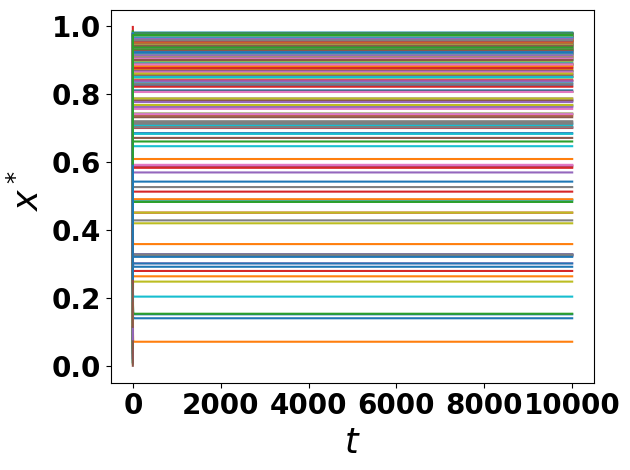

In [12]:
T_max = 10000  
t_eval = np.linspace(0, T_max, 10000)
beta = 0.5
theo_avg = []
theo_star = []
theo_star1 = []

#network_data = scipy.io.loadmat('C:/Users/Admin/Desktop/python/work_1/Tim_sug/A_20_35.mat')
#mat_file = network_data['A']
#G_ba = nx.barabasi_albert_graph(N, m)
#A = nx.to_numpy_array(G_ba)
#A = np.array(A)

#N = len(A)

degree=np.sum(A, axis=0)
avg=np.mean(degree)


def dxdt(t, x, beta, A):
    return -x + beta * (1 - x) * (A @ x)

x0 = np.random.rand(N)

sol = solve_ivp(dxdt, [0, T_max], x0, args=(beta, A), t_eval=t_eval, rtol=1e-6, atol=1e-8)
    


plt.xticks(fontsize=20,fontweight='bold')
plt.yticks(fontsize=20,fontweight='bold')


for i in range(N):
    plt.plot(t_eval, sol.y[i])

plt.xlabel(r'$t$', fontsize=25,fontweight='bold')
plt.ylabel(r' $ x^*$', fontsize=25,fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
N = len(A)
degree = np.sum(A, axis=0)
avg = np.mean(degree)
N = len(A)
degree = np.sum(A, axis=0)
avg = np.mean(degree)
print (N)
print (degree)
print(avg)

293
[ 89.   6.  96.  10.  13.  17.  31.   2.  73.  25.   5.  30.   1.  53.
  39.   1.  17. 106.   2.  24.   6.  27.  31.  24.   1.   6.  20.  47.
  12.   5.  30.  70.  60.  10.   1.  50.   7.  36.  20.   2. 106.  17.
  53.  80.   3.   1.   9.  57.  19.   4.   8.   6.  52.   2.  35.  14.
  47.  75.  64.  11.   2.  41.  89.   3.  57.   8.  77.  16.  97.   2.
  10.  16.  30.  47.  15.  24.   3.  41.  14.   1.  62.  33.   5.   1.
   7.  12.  25.  76.  36.  45.   1.  65.  69.  75.  67.  25.  30.  21.
  14.   6.  54.  34.  51.   5.   8.  51.  48.  75.  54.  17.   3.  69.
  30.  38.  17.  21.  23.  47.  36.  50.  76.  30.  14.   3.  50.  14.
  96.   6.   2.  90.  24.  15.  26.  22.  15.   9.  13.  52.  29. 105.
   1.  55.   2.  46.   3.  55.  23.  33.  37. 105.  36.   4.  75.  92.
  77.  12.  14.  11.  61.  19.  59.  59.  23.  44.  63.  12.   3.  26.
  68.  18.   9.  43.   2.  46.  39.   8.  55.  13.  55.  23.  19.   1.
  36.  79.  73.  93.   5.  36.  67.   5.  40.  22.   7.  70.   1.  13.
  

In [4]:
print("Matrix shape:", A.shape)
print("Number of nodes:", N)


Matrix shape: (293, 293)
Number of nodes: 293


In [7]:
np.save("near_xstar.npy", x_star_values)
np.save("near_xtime.npy", sol.y.mean(axis=0))